# Header: Sensitivity gradient for surveys of the HT-ATES site (version 1)

**Research setting:** hot water is injected into a shallow aquifer at the HT-ATES site in Delft. We investigate the use of a surface-to-borehole CSEM monitoring set-up for recovering the shape of the hot plume that develops.

**Based on:** The EASYGO summer school exercises: https://github.com/emsig/easygo-training-em/blob/main/emg3d_ATES.ipynb


## Version 1.3: Manual computation

Simplify and coarsen the simulation in order to compare with finite-difference method

## Version 1: Sensitivity gradient for FMv1.2 survey design

We want to use a selection of sources determined through the v1.2 forward-modelling script. In the basic configuration, 6 sources are used which are both x- and y-directed. In this script, we compute the response to a buoyant hot plume generated in COMSOL.

Hot plume: generated through a COMSOL model for homogeneous aquifer (not site-specific)
Resistivity model: based on the interpretation by Marco Bortollotti

It will be of interest to see if there are changes in the measured signal at the receiver due to this hot plume that is not present at the receivers itself (a requirement for DTS-based monitoring). The survey design will be tested to investigate when this sensitivity is the highest.

## Limitations

The receivers used in this forward-modeling are point-based receivers, which does not accurately represent the measurement. The real receivers will be of 0.5 m in length and spaced by 7.5 m. It was decided to implement the spacing (7.5 m) but not the size of the receivers for now. Source length is also not included in this version. Empymod could be used to test if the size of the receivers makes a difference to the measurement. It would also be good to consider the capacitive coupling of the receivers and whether this makes a difference to the acquired signal.

Additional investigations should include: comparison with surface-to-surface measurements, inversion of synthetic data, investigation of different survey designs, investigate impact of the production well steel casing and placing sources close to the production well (magnification of the source signal at depth), effect of well-deviation and Ex component, effect of vertical sources in DTS wells

# Code

In [2]:
import emg3d
import empymod
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize

plt.style.use('bmh')

# Comment this out on Google Colab
#%matplotlib widget

## Functions

In [3]:
#define interpolation functions
def find_distance2d(coord1, coord2):
    distance = (coord1[0]-coord2[0])**2+(coord1[1]-coord2[1])**2
    return distance
    #This is the distance squared but it should work the same

def interpolate2d(location, array):
    dis = []
    for i in np.arange(len(array)):
        dis.append(find_distance2d(location, array[i]))
    return np.argmin(dis)

### Selecting cuboids from the grid

In [4]:
def point2index_xyz(grid, point, QC=False):
    #Assumes that 
    
    x_spacing = min(grid.h[0])
    y_spacing = min(grid.h[1])
    z_spacing = min(grid.h[2])

    grid_center_i = int((grid.n_cells+grid.shape_cells[0]*grid.shape_cells[1]+ grid.shape_cells[0])/2)
    grid_center =  grid.cell_centers[grid_center_i]

    ix_steps = int((point[0]-grid_center[0])/x_spacing)
    iy_steps = int((point[1]-grid_center[1])/y_spacing)
    iz_steps = int((point[2]-grid_center[2])/z_spacing)
    
    ix = int(grid.shape_cells[0]/2)+ix_steps
    iy = int(grid.shape_cells[1]/2)+iy_steps
    iz = int(grid.shape_cells[2]/2)+iz_steps

    if grid.h[0][int(grid.shape_cells[0]/2)] != x_spacing:
        print('Warning: no homogeneous x-spacing')
    if grid.h[1][int(grid.shape_cells[1]/2)] != y_spacing:
        print('Warning: no homogeneous y-spacing')
    if grid.h[2][int(grid.shape_cells[2]/2)] != z_spacing:
        print('Warning: no homogeneous z-spacing')

    if QC==True:
        print('x: ', grid.cell_centers_x[ix])
        print('y: ', grid.cell_centers_y[iy])
        print('z: ', grid.cell_centers_z[iz])

    return ix, iy, iz

In [5]:
def find_cuboid_indeces_xyz(grid, x_extent, y_extent, zmin, zmax, QC=True):

    cornerpoint1 = [-x_extent, -y_extent, zmin]
    cornerpoint2 = [x_extent, y_extent, zmax]

    if QC==True:
        print(cornerpoint1, cornerpoint2)
    
    ix_min, iy_min, iz_min = point2index_xyz(grid, cornerpoint1, QC=False)
    ix_max, iy_max, iz_max = point2index_xyz(grid, cornerpoint2, QC=False)

    return ix_min, iy_min, iz_min, ix_max, iy_max, iz_max

In [6]:
def change_cuboid_resistivity(res_orig, grid, x_extent, y_extent, zmin, zmax, target_res):
    #Assumes that cuboid will be created around x=0 and y=0
    #Only works for grids that are symmetric around the origin in the number of cells

    ix_min, iy_min, iz_min, ix_max, iy_max, iz_max = find_cuboid_indeces_xyz(grid, x_extent, y_extent, zmin, zmax)

    #QC the bounds
    print('x bounds: ', grid.cell_centers_x[ix_min], ' , ', grid.cell_centers_x[ix_max])
    print('y_bounds: ', grid.cell_centers_y[iy_min], ' , ', grid.cell_centers_y[iy_max])
    print('z_bounds: ', grid.cell_centers_z[iz_min], ' , ', grid.cell_centers_z[iz_max])

    # Set target resistivity of the cuboid
    res_new = res_orig
    res_new[ix_min:ix_max, iy_min:iy_max, iz_min:iz_max] = target_res

    return res_new

### Manual plotting of values (vs. plot_slice)
This is done to enable comparison with empymod

To compare with empymod, we crop the field values to the inner domain by finding the boundary indeces.
Note: we can only use the inner domain where no cell stretching is taking place: y = [-300, 300], z = [-250, -5] & cell width is constant

Note about plotting:

When using plot_slice, the simulation output is interpolated to the cell centers, which results in a slightly different plot than when the output is directly plotted using matplotlib. Especially beneath the source this is visible, as the field value should be 0 there but this is not shown if the field value is not sampled (or interpolated) to that exact point.

I have chosen here to use the matplotlib plotting, and to accept the inaccuracy below the source, as this makes it easier to compare results between emg3d and empymod

In [7]:
def crop_to_domain(efield3D, grid, x_slice = 0, y_extent=300, zmin=-250, zmax=0):

    #This method assumes cell_centers are the relevant parameters
    ix_min, iy_min, iz_min, ix_max, iy_max, iz_max = find_cuboid_indeces_xyz(grid, x_slice, y_extent, zmin, zmax, QC=True)

    #QC the bounds
    print('x position: ', grid.nodes_x[ix_max])
    print('y_bounds: ', grid.nodes_y[iy_min], ' , ', grid.nodes_y[iy_max+1])
    print('z_bounds: ', grid.cell_centers_z[iz_min], ' , ', grid.cell_centers_z[iz_max])

    # Crop Ez field array
    crop_efield3D = efield3D.fz[ix_max, iy_min:iy_max+2, iz_min:iz_max+1]
    crop_efield3D = np.flip(np.transpose(crop_efield3D), axis=0)

    return crop_efield3D

In [8]:
def manual_plot_slice(efield, grid, y_extent=300, zmin=-250, zmax=0, size_y = 6.4, size_z = 4.8, vmin = 1e-7, vmax = 1e-6, norm = 'log'):
    
    fig, ax = plt.subplots()
    plt.imshow(np.abs(efield), extent = [0, size_y, 0, size_z], norm=norm, vmin = vmin, vmax = vmax)
    ax.set_title('Field')
    #ax.set_xlabel('Offset (km)')
    #ax.set_ylabel('Depth (1e2 m)')
    plt.colorbar(location='right', fraction=0.035)
    plt.xticks(np.arange(0, size_y, size_y/4), np.arange(-y_extent, y_extent, y_extent/2))
    plt.yticks(np.arange(0, size_z, size_z/4), np.arange(zmin, zmax, (zmax-zmin)/4))
    plt.grid(False)
    plt.show()

In [9]:
def manual_plot_slice_3x(efield1, efield2, efield3, y_extent=-300, zmin=-250, zmax=0, size_y = 6.4, size_z = 4.8, vmin = 1e-8, vmax = 1e-4):

    fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(15,5))

    ax1_plot = ax1.imshow(np.abs(efield1), extent = [0, size_y, 0, size_z], norm='log', vmin = vmin, vmax = vmax)
    ax1.set_title('Field 1 |Ez| (V/m)')
    ax1.set_xlabel('y (m)')
    ax1.set_ylabel('z (m)')
    plt.colorbar(ax1_plot, location='bottom')
    ax1.set_xticks(np.arange(0, size_y, size_y/4), np.arange(-y_extent, y_extent, y_extent/2))
    ax1.set_yticks(np.arange(0, size_z, size_z/4), np.arange(zmin, zmax, (zmax-zmin)/4))
    ax1.grid(False)
    
    ax2_plot = ax2.imshow(np.abs(efield2), extent = [0, size_y, 0, size_z], norm='log', vmin = vmin, vmax = vmax)
    ax2.set_title('Field 2 |Ez| (V/m)')
    ax2.set_xlabel('y (m)')
    ax2.set_ylabel('z (m)')
    plt.colorbar(ax2_plot, location='bottom')
    ax2.set_xticks(np.arange(0, size_y, size_y/4), np.arange(-y_extent, y_extent, y_extent/2))
    ax2.set_yticks(np.arange(0, size_z, size_z/4), np.arange(zmin, zmax, (zmax-zmin)/4))
    ax2.grid(False)
    
    ax3_plot = ax3.imshow(np.abs(efield3), extent = [0, size_y, 0, size_z], norm='log', vmin = vmin, vmax = vmax)
    ax3.set_title('Field 3 |Ez| (V/m)')
    ax3.set_xlabel('y (m)')
    ax3.set_ylabel('z (m)')
    plt.colorbar(ax3_plot, location='bottom')
    ax3.set_xticks(np.arange(0, size_y, size_y/4), np.arange(-y_extent, y_extent, y_extent/2))
    ax3.set_yticks(np.arange(0, size_z, size_z/4), np.arange(zmin, zmax, (zmax-zmin)/4))
    ax3.grid(False)

## Survey & grid for models >>> EDIT SURVEY DESIGN HERE

**In contrast to forward-modeling scripts, to calculate the sensitivity gradient in Emg3d it is required to use the 'surveys' class. This allows the inclusion of multiple sources in the investigation as well as different resistivity scenarios, between which a sensitivity gradient can be computed. The survey class brings difficulties as care should be taken that simulations and surveys have the correct name! Each survey should have its own name, or will be overwriting other versions.**

- The hot plume is centred at x=0, y=0
- Receiver is located at x=0, y=74
- Depth is negative!

In [10]:
# Create a survey

# Acquisition source frequencies (Hz)
frequencies = [1.0]

# Source coordinates, a survey consisting of 6 surface sources including y-directed and x-directed sources at 35-100 m distance
src = emg3d.surveys.txrx_coordinates_to_dict(
        emg3d.TxElectricDipole,
        (0, -75, 0, 90.0, 0.0)
)

colors = ['blue']

# Receiver positions, vertical z-directed point dipoles
rec_x = np.arange(1, 11)*0
rec_y = np.array([74]*10)
rec_z = np.arange(1,11)*-30
rec = emg3d.surveys.txrx_coordinates_to_dict(
        emg3d.RxElectricPoint,
        (rec_x, rec_y, rec_z, 0.0, 90.0)
)

In [11]:
survey = emg3d.surveys.Survey(
    name='Example survey, not used',  # Name of the survey
    sources=src,               # Source coordinates
    receivers=rec,             # Receiver coordinates
    frequencies=frequencies,   # Two frequencies
    # data=data,               # If you have observed data
    #noise_floor=1e-15,
    #relative_error=0.01,
)

# Let's have a look at the survey:
survey

:: Survey «Example survey, not used» ::

<xarray.Dataset> Size: 476B
Dimensions:   (src: 1, rec: 10, freq: 1)
Coordinates:
  * src       (src) <U6 24B 'TxED-1'
  * rec       (rec) <U7 280B 'RxEP-01' 'RxEP-02' ... 'RxEP-09' 'RxEP-10'
  * freq      (freq) <U3 12B 'f-1'
Data variables:
    observed  (src, rec, freq) complex128 160B (nan+nanj) ... (nan+nanj)
Attributes:
    noise_floor:     None
    relative_error:  None

In [12]:
grid = emg3d.construct_mesh(
    center=(0,0,0),                                 # Center of wanted grid
    frequency=frequencies[0],                            # Frequency we will use the grid for
    properties=[25],                       # Reference resistivity
    domain=([-100, 100], [-100, 100], [-250, 0]),   # Domain in which we want precise results
    center_on_edge=True,
    min_width_limits = [50, 50, 25],
)
 
grid  # mesh info
#grid.plot_grid() # plotting the grid

TensorMesh: 40,960 cells

                      MESH EXTENT             CELL WIDTH      FACTOR
  dir    nC        min           max         min       max      max
  ---   ---  ---------------------------  ------------------  ------
   x     32    -16,249.87     16,249.87     50.00  4,486.78    1.38
   y     32    -16,249.87     16,249.87     50.00  4,486.78    1.38
   z     40    -16,645.59     24,075.36     25.00  7,654.77    1.46

## Subsurface models >>> EDIT MODELS TO USE HERE

### Uniform halfspace model

In [13]:
#Uniform resistivity model with only air interface included and 33 Ohmm resistivity everywhere (average of Bortollotti values)
depth = [0]

# Layer resistivities in Ohm.m
resistivities_unif = np.array([1e8, 33.0]) # base incl. air (lower res, because of 3D modelling)

# Pre-allocate an array with number of cells corresponding to our grid
res = np.ones(grid.shape_cells)

# Layered base model: Fill in layered resistivities into our grid
dd = np.r_[np.inf, depth, -np.inf]
for i in range(len(resistivities_unif)):
    res[:, :, (grid.cell_centers_z > dd[i+1]) & (grid.cell_centers_z <= dd[i])] = resistivities_unif[i]

# Create the homogenous 25 kOhm model
model_unif = emg3d.Model(grid, property_x=res, mapping='Resistivity')

NameError: name 'src_x' is not defined

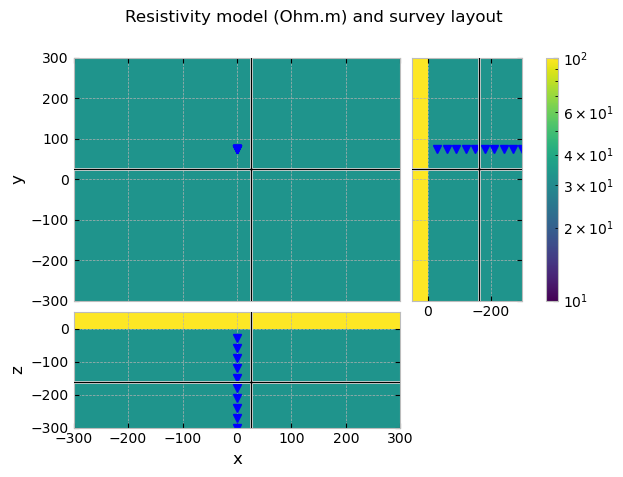

In [14]:
# Plot/QC the model
grid.plot_3d_slicer(
    model_unif.property_x,
    pcolor_opts={'norm': LogNorm(vmin=10, vmax=100)},
    xlim=[-300, 300],
    ylim=[-300, 300],
    zlim=[-300, 50],
    zslice=-160,
)
# Plot survey in figure above
fig = plt.gcf()
fig.suptitle('Resistivity model (Ohm.m) and survey layout')
axs = fig.get_children()
rec_coords = [rec_x, rec_y, rec_z]
axs[1].plot(rec_coords[0], rec_coords[1], 'bv')
axs[2].plot(rec_coords[0], rec_coords[2], 'bv')
axs[3].plot(rec_coords[2], rec_coords[1], 'bv')
src_coords = [src_x, src_y, src_z]
axs[1].plot(src_coords[0], src_coords[1], 'r*')
axs[2].plot(src_coords[0], src_coords[2], 'r*')
axs[3].plot(src_coords[2], src_coords[1], 'r*')
axs[1].grid(False)
axs[2].grid(False)
axs[3].grid(False)

### Baseline layered model

In [16]:
#Baseline resistivity model from Bortolotti

# We idealize the depth model here a bit, to have cells of 10m in depth
depth = [0, -50, -80, -120, -190]

# Layer resistivities in Ohm.m for the baseline
resistivities_base = np.array([1e8, 52.0, 38.0, 26.0, 29.5, 17.5]) # base incl. air (lower res, because of 3D modelling)

# Pre-allocate an array with number of cells corresponding to our grid
res_base = np.ones(grid.shape_cells)

# Layered base model: Fill in layered resistivities into our grid and create model
dd = np.r_[np.inf, depth, -np.inf]
for i in range(len(resistivities_base)):
    res_base[:, :, (grid.cell_centers_z > dd[i+1]) & (grid.cell_centers_z <= dd[i])] = resistivities_base[i]

model_base = emg3d.Model(grid, property_x=res_base, mapping='Resistivity')

NameError: name 'src_x' is not defined

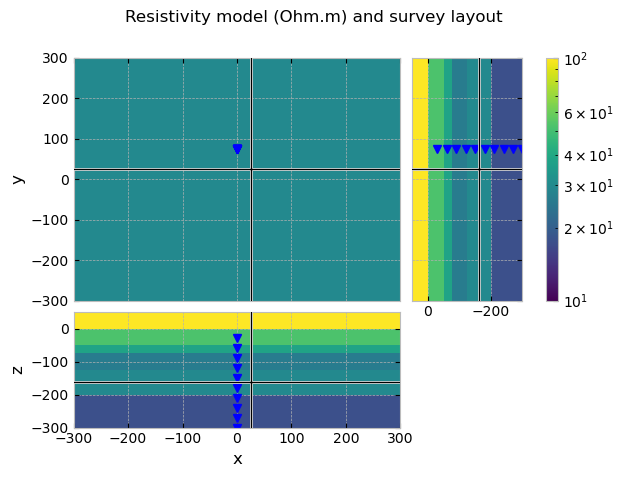

In [17]:
# Plot/QC the model
grid.plot_3d_slicer(
    model_base.property_x,
    pcolor_opts={'norm': LogNorm(vmin=10, vmax=100)},
    xlim=[-300, 300],
    ylim=[-300, 300],
    zlim=[-300, 50],
    zslice=-160,
)
# Plot survey in figure above
fig = plt.gcf()
fig.suptitle('Resistivity model (Ohm.m) and survey layout')
axs = fig.get_children()
rec_coords = [rec_x, rec_y, rec_z]
axs[1].plot(rec_coords[0], rec_coords[1], 'bv')
axs[2].plot(rec_coords[0], rec_coords[2], 'bv')
axs[3].plot(rec_coords[2], rec_coords[1], 'bv')
src_coords = [src_x, src_y, src_z]
axs[1].plot(src_coords[0], src_coords[1], 'r*')
axs[2].plot(src_coords[0], src_coords[2], 'r*')
axs[3].plot(src_coords[2], src_coords[1], 'r*')
axs[1].grid(False)
axs[2].grid(False)
axs[3].grid(False)

### Hot plume generated in COMSOL

#### Insert custom plume

In [18]:
#Use predefined function to insert a cuboid inton the target layer

x_extent = 150
y_extent = 150
zmin = depth[4]
zmax = depth[3]
res_QC = 13.1 #now: aquifer +50 °Celsius

res_QC = change_cuboid_resistivity(res_base.copy(), grid, x_extent, y_extent, zmin, zmax, res_QC)

model_QC = emg3d.Model(grid, property_x=res_QC, mapping='Resistivity')

[-150, -150, -190] [150, 150, -120]
x bounds:  -134.4696969696976  ,  134.46969696969634
y_bounds:  -134.4696969696976  ,  134.46969696969634
z_bounds:  -187.49999999999852  ,  -112.49999999999852


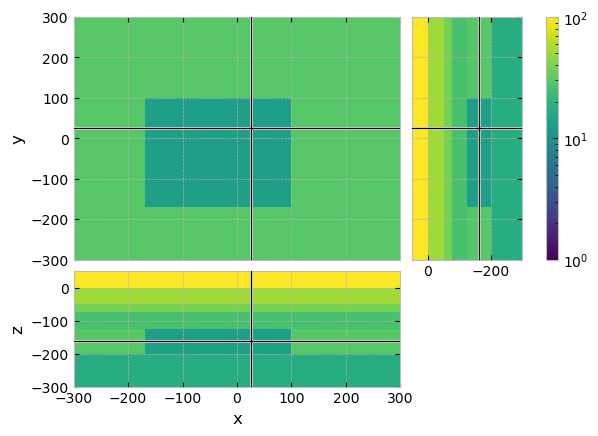

In [19]:
#QC cube location
grid.plot_3d_slicer(
    model_QC.property_x,
    pcolor_opts={'norm': LogNorm(vmin=1, vmax=100)},
    xlim=[-300, 300],
    ylim=[-300, 300],
    zlim=[-300, 50],
    zslice=-160,
)
fig = plt.gcf()

In [20]:
#insert custom hot plume values [SKIP TO NEXT STEP IF RES FILE IS ALREADY SAVED]

#Load custom plume data
comsol_plume = np.loadtxt('test_plume_2.txt', skiprows=8) #data columns: radius, depth, temperature (K)

#crop data array to limit interpolation time
plume_crop = []
for i in np.arange(len(comsol_plume[:,0])):
    if comsol_plume[i,0] < 150 and comsol_plume[i,1] > depth[4] and comsol_plume[i,1] < depth[3]:
        plume_crop.append(comsol_plume[i])

ix_min, iy_min, iz_min, ix_max, iy_max, iz_max = find_cuboid_indeces_xyz(grid, x_extent, y_extent, zmin, zmax)

#interpolate temperature values and insert into 1d custom plume array
#To prevent edge effects, we assume that the min. temperature in the custom plume array is the original temperature of the aquifer before injection
rho_cold = resistivities_base[4]
T_cold = min(np.array(plume_crop)[:,2])
res_target3 = res_base.copy()
for ix in np.arange(ix_min, ix_max+1):
    for iy in np.arange(iy_min, iy_max+1):
        for iz in np.arange(iz_min, iz_max+1):
            loc = [grid.cell_centers_x[ix], grid.cell_centers_y[iy], grid.cell_centers_z[iz]] #select a cell coordinate from our grid
            radius = np.sqrt(loc[0]**2+loc[1]**2)
            loc2d = np.array([radius, loc[2]]) #flatten to 2d coordinates
            T_hot = plume_crop[interpolate2d(loc2d, plume_crop)][2] #find temperature value of COMSOL data point closest to this cell
            res_target3[ix, iy, iz] = rho_cold/(1+0.020*(T_hot-T_cold)) #translate to resistivity

#Save as new file in flattened form
np.savetxt('test_plume_2_coarsely_interpolated.txt', res_target3.ravel('F'))

[-150, -150, -190] [150, 150, -120]


#### Load desired plume file

Possible plumes to use:
- 'test_plume_1_interpolated.txt': a small plume that reflects ... day injection in the default aquifer used by Gao et al.
- 'test_plume_2_interpolated.txt': a large plume that reflects ... day injection in the default aquifer used by Gao et al.

In [21]:
#load existing custom plume resistivities
res_target = np.loadtxt('test_plume_2_coarsely_interpolated.txt')
#print(np.shape(res_plume))

model_target = emg3d.Model(grid, property_x=res_target, mapping='Resistivity')

NameError: name 'src_x' is not defined

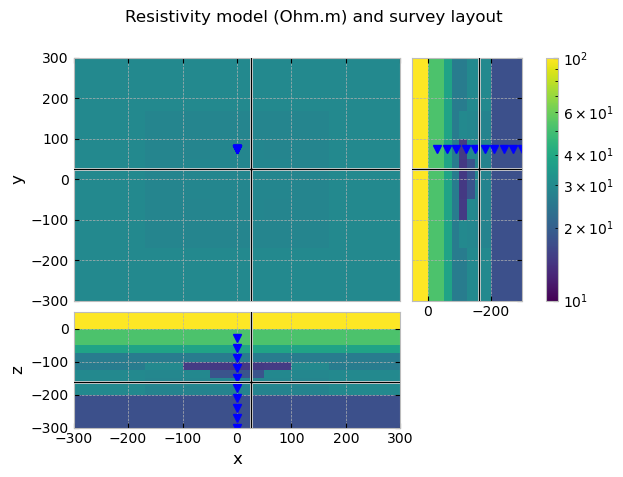

In [22]:
# Plot/QC the model with the 3D target
grid.plot_3d_slicer(
    model_target.property_x,
    pcolor_opts={'norm': LogNorm(vmin=10, vmax=100)},
    xlim=[-300, 300],
    ylim=[-300, 300],
    zlim=[-300, 50],
    zslice=-160,
)
# Plot survey in figure above
fig = plt.gcf()
fig.suptitle('Resistivity model (Ohm.m) and survey layout')
axs = fig.get_children()
rec_coords = [rec_x, rec_y, rec_z]
axs[1].plot(rec_coords[0], rec_coords[1], 'bv')
axs[2].plot(rec_coords[0], rec_coords[2], 'bv')
axs[3].plot(rec_coords[2], rec_coords[1], 'bv')
src_coords = [src_x, src_y, src_z]
axs[1].plot(src_coords[0], src_coords[1], 'r*')
axs[2].plot(src_coords[0], src_coords[2], 'r*')
axs[3].plot(src_coords[2], src_coords[1], 'r*')
axs[1].grid(False)
axs[2].grid(False)
axs[3].grid(False)

NameError: name 'src_coords' is not defined

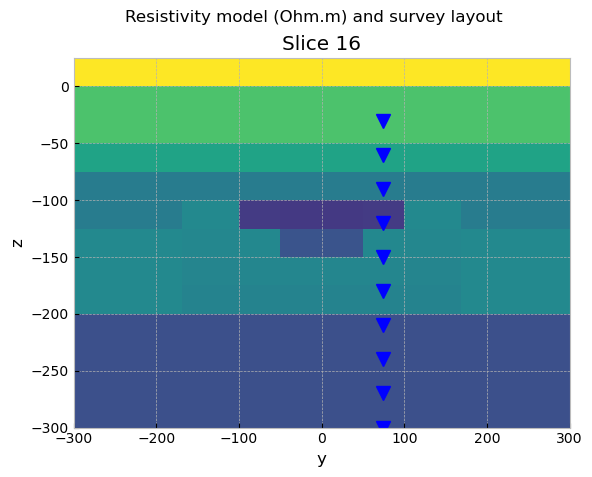

In [23]:
#Focus on the y,z plane
grid.plot_slice(
    model_target.property_x,
    normal = 'X',
    pcolor_opts={'norm': LogNorm(vmin=10, vmax=100)},
    range_x=[-300, 300],
    range_y=[-300, 25],
#    slice_loc=0
)
fig = plt.gcf()
fig.suptitle('Resistivity model (Ohm.m) and survey layout')
axs = fig.get_children()
axs[1].plot(rec_coords[1], rec_coords[2], 'bv', markersize = 10)
axs[1].plot(src_coords[1], src_coords[2], 'r*', markersize = 20)
axs[1].grid(False)

## Simulations

### Gridding options

The grid is adapted during the running of the Simulation, the below options are passed to the Simulation to constrain these grids

In [24]:
#Generate frequency- and source-dependent grids
gopts = {
    'properties': [25],
    'min_width_limits': [50, 50, 25],
    #'stretching': (None, None, [1.0, 1.5]),
    'domain': (
        [-100, 100],
        [-100, 100],
        [-250, 0]
    ),
    'center_on_edge': False,
}

### Select which models to use where >>> EDIT SENSITIVITY DETAILS HERE

Two simulations are included:
- We test if it is possible to recover the baseline layered structure using the given survey design, by calculating the misfit and sensitivity gradient against a homogeneous halfspace 33 Ohmm starting model
- We test if it is possible to recover the hot plume model using the given survey design, (...)

**You can edit the below to investigate different things. All the calculations should then be automatically adapted.**

In [78]:
#Save models in a dictionary

models = {} # Contains [model, extended name
models['Uniform'] = [model_unif, 'Uniform halfspace 33 Ohmm']
models['Baseline'] = [model_base, 'Baseline layered model']
models['Target'] = [model_target, 'Layered model + COMSOL test plume 2']
#Values added later: survey containing the model and noise information

# Create a dictionary for the simulations to compute

simulations = {} # Contains [reference model key, measured model key]
#simulations['Sensitivity base v unif'] = ['Uniform', 'Baseline']
simulations['Sensitivity target v base'] = ['Baseline', 'Target']
#Values added later: simulation measured data, simulation reference, gradient

noise_floor = 1e-20
relative_error = 0.001

### Forward-modeling of the measured data

In [79]:
#Create a survey design to generate measured data for each model (they are all the same, but have different names)

for i in np.arange(len(models.keys())):
    model_key = list(models.keys())[i]

    #The survey incorporates the src-rec positions and the noise recorded during measurement
    noisy_survey = emg3d.surveys.Survey(
        name='Noisy survey: '+models[model_key][1],  # Name of the survey
        sources=src,               # Source coordinates
        receivers=rec,             # Receiver coordinates
        frequencies=frequencies,   # Two frequencies
        # data=data,               # Adding the observed data here will allow sensitivity calculation later, but we need to generate it first
        noise_floor=noise_floor,
        relative_error=relative_error,
    )

    #Add surveys to model dictionary
    models[model_key] = [models[model_key][0], models[model_key][1], noisy_survey] 

In [80]:
# Create simulations (forward-modeling) for the models we want

for i in np.arange(len(simulations.keys())):
    sim_key = list(simulations.keys())[i]
    meas_model = simulations[sim_key][1]

    #The simulation class contains all that is needed to forward-model the measurement: survey, model, grid, and solving parameters
    simulation = emg3d.simulations.Simulation(
            name='Noisy simulation: '+models[meas_model][1],    # A name for this simulation
            survey=models[meas_model][2],        # Our survey instance
            model=models[meas_model][0],          # The model
            gridding='both',      # Frequency- and source-dependent meshes
            max_workers=4,        # How many parallel jobs
            # solver_opts,        # Any parameter to pass to emg3d.solve
            gridding_opts=gopts,  # Gridding options
            receiver_interpolation = "linear" #Needed for correct computation of the gradient
        )

    #Add simulations to simulations dictionary
    simulations[sim_key] = [simulations[sim_key][0], simulations[sim_key][1], simulation]

In [81]:
#Compute the measured efields

for i in np.arange(len(simulations.keys())):
    sim_key = list(simulations.keys())[i]
    simulation = simulations[sim_key][2]
    simulation.compute(observed=True)
    print('Measured data for: '+sim_key+' computed')

#The version without noise is stored in the survey as 'synthetic' and version with noise as 'observed'

Compute efields            0/1  [00:00]

Measured data for: Sensitivity target v base computed


In [82]:
plt.rcParams.update({'font.size':10})
plt.rcParams.update({'lines.linewidth':1.0})

#### Plots for QC of forward-models

C:\Users\suzannevannoor\AppData\Local\Temp\ipykernel_14736\3298003798.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(ncol=1, framealpha=0)


(1e-10, 0.001)

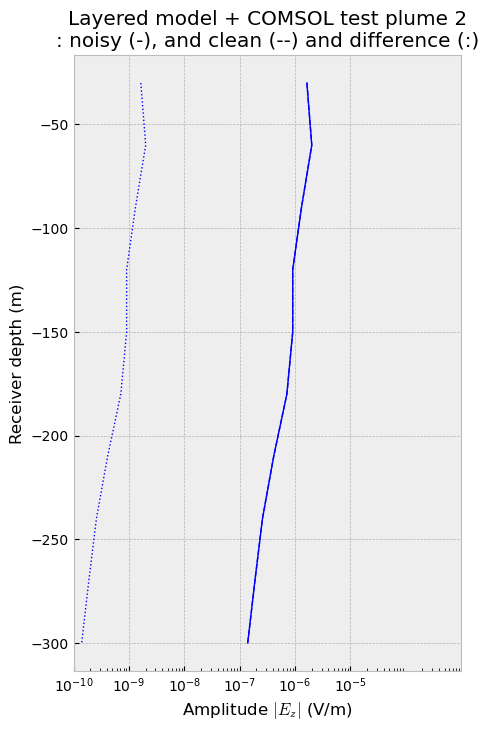

In [85]:
#QC receiver lines for all the sources

sim_nr = 0

sim_key = list(simulations.keys())[sim_nr]
simulation = simulations[sim_key][2]
model_name = models[simulations[sim_key][1]][1]

plt.figure(figsize=(5,8))
plt.title(''''''+model_name+'''
: noisy (-), and clean (--) and difference (:)''')
noisy = simulation.data.observed[:, :, :]
clean = simulation.data.synthetic[:, :, :]
noise = noisy - clean
for i, srcn in enumerate(simulation.survey.sources):
    for ii, freq in enumerate(simulation.survey.frequencies):
        plt.plot(np.sqrt(noisy.loc[srcn, :, freq].data.real**2 + noisy.loc[srcn, :, freq].data.imag**2),
                 rec_coords[2][:],
                color = colors[i],
                 #label='xya: '+str(src_x[i])+', '+str(src_y[i])+', '+str(src_az[i]) # else None
                 )
        plt.plot(np.sqrt(clean.loc[srcn, :, freq].data.real**2 + clean.loc[srcn, :, freq].data.imag**2),
                 rec_coords[2][:],
                 '--',
                 color = colors[i],
                 )
        plt.plot(np.sqrt(noise.loc[srcn, :, freq].data.real**2 +  noise.loc[srcn, :, freq].data.imag**2),
         rec_coords[2][:],
         ':',
         color = colors[i],
         )
plt.xscale('log')
plt.legend(ncol=1, framealpha=0)
plt.ylabel('Receiver depth (m)')
plt.xlabel('Amplitude $|E_z|$ (V/m)')
ticks, labels = plt.xticks()
plt.xticks(ticks[1:-1])
plt.xlim([1e-10, 1e-3])

#The relative noise dominates and has amplitude of 1% of the data

In [74]:
print(simulations)

{'Sensitivity target v base': ['Baseline', 'Target', :: Simulation «Noisy simulation: Layered model + COMSOL test plume 2» ::

- Survey «Noisy survey: Layered model + COMSOL test plume 2»: 1 sources; 10 receivers; 1 frequencies
- Model: resistivity; isotropic; 32 x 32 x 40 (40,960)
- Gridding: Frequency- and source-dependent grids; 32 x 32 x 40 (40,960), :: Simulation «Simulation: Sensitivity target v base» ::

- Survey «Noisy survey: Layered model + COMSOL test plume 2»: 1 sources; 10 receivers; 1 frequencies
- Model: resistivity; isotropic; 32 x 32 x 40 (40,960)
- Gridding: Frequency- and source-dependent grids; 32 x 32 x 40 (40,960), array([[[ 6.15250594e-14,  3.08322103e-13, -1.83524245e-12, ...,
         -4.97910011e-20, -3.79719289e-20, -1.16063228e-20],
        [ 4.63623491e-13, -4.15275993e-12, -7.22985481e-12, ...,
         -1.03033372e-19, -7.70642741e-20, -2.42401124e-20],
        [-3.73860049e-13, -5.38868602e-12,  1.12073313e-11, ...,
         -1.22308069e-19, -8.74462139e

[0, -300, -250] [0, 300, 0]
x position:  24.99999999999943
y_bounds:  -575.7505427216491  ,  575.7505427216479
z_bounds:  -249.99999999999852  ,  -24.999999999998522
[0, -300, -250] [0, 300, 0]
x position:  24.99999999999943
y_bounds:  -575.7505427216491  ,  575.7505427216479
z_bounds:  -249.99999999999852  ,  -24.999999999998522
[0, -300, -250] [0, 300, 0]
x position:  24.99999999999943
y_bounds:  -575.7505427216491  ,  575.7505427216479
z_bounds:  -249.99999999999852  ,  -24.999999999998522


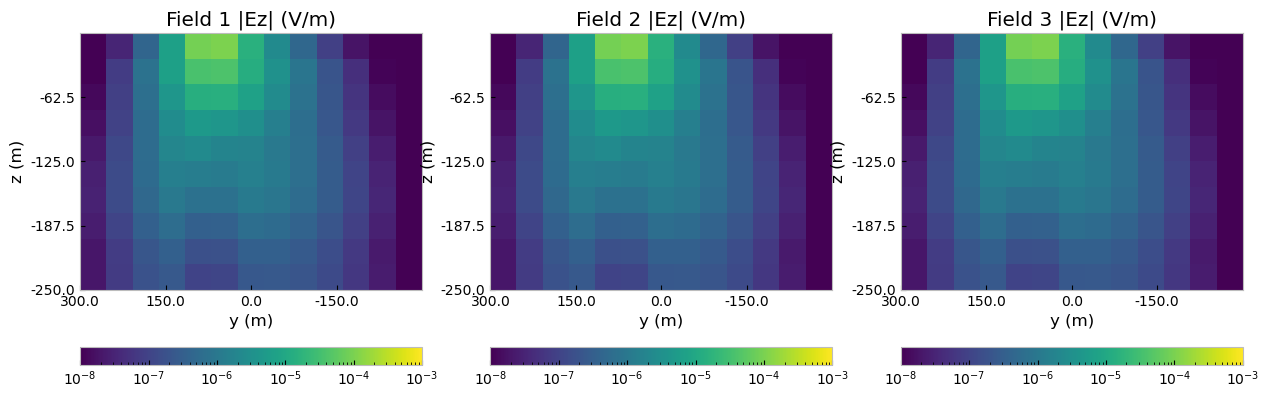

In [86]:
#QC total efields for different sources

sim_nr = 0
src_nr_1 = 0
src_nr_2 = 0
src_nr_3 = 0
fr_nr = 0

sim_key = list(simulations.keys())[sim_nr]
simulation = simulations[sim_key][2]
new_grid = simulation.get_grid(list(src)[src_nr_1], frequencies[fr_nr])
efield1 = simulation.get_efield(list(src)[src_nr_1], frequencies[fr_nr])
efield2 = simulation.get_efield(list(src)[src_nr_2], frequencies[fr_nr])
efield3 = simulation.get_efield(list(src)[src_nr_3], frequencies[fr_nr])
efield1 = crop_to_domain(efield1, new_grid, x_slice = 0, y_extent=300, zmin=-250, zmax=0)
efield2 = crop_to_domain(efield2, new_grid, x_slice = 0, y_extent=300, zmin=-250, zmax=0)
efield3 = crop_to_domain(efield3, new_grid, x_slice = 0, y_extent=300, zmin=-250, zmax=0)

manual_plot_slice_3x(efield1, efield2, efield3, y_extent=-300, zmin=-250, zmax=0, size_y = 6.4, size_z = 4.8, vmin = 1e-8, vmax = 1e-3)
#edit_manual_plot_slice_3x(efield1, efield2, efield3, y_extent=-300, zmin=-250, zmax=0, size_y = 6.4, size_z = 4.8, vmin = 1e-8, vmax = 1e-3)

### Forward-modeling of reference and gradient calculation

The survey we generated before now has observed data in it. We can continue with forward-modeling the reference (initial model) whilst this data (and the noise it contains) is encoded in the survey class.

In [87]:
#The survey we generated before now has observed data in it

for i in np.arange(len(simulations.keys())):
    sim_key = list(simulations.keys())[i]
    simulation = simulations[sim_key][2]
    ref_model_key = simulations[sim_key][0]
    meas_model_key = simulations[sim_key][1]

    #The simulation contains the measured data (through the survey) and the details needed to forward-model the reference
    ref_model_key = simulations[sim_key][0]
    grad_simulation = emg3d.simulations.Simulation(
        name='Simulation: '+sim_key,    # A name for this simulation
        survey=models[meas_model_key][2],        # Our survey instance
        model=models[ref_model_key][0],      # The model
        gridding='both',      # Frequency- and source-dependent meshes
        max_workers=4,        # How many parallel jobs
        # solver_opts,        # Any parameter to pass to emg3d.solve
        gridding_opts=gopts,  # Gridding options
        receiver_interpolation = "linear" # Needed for correct computation of the gradient
    )

    #Add to dictionary
    simulations[sim_key] = [simulations[sim_key][0], simulations[sim_key][1], simulations[sim_key][2], grad_simulation]

In [88]:
#Compute the measured efields for the reference measurement and compute the gradient

for i in np.arange(len(simulations.keys())):
    sim_key = list(simulations.keys())[i]
    grad_simulation = simulations[sim_key][3]
    grad_simulation.compute()
    print('Reference data for: '+sim_key+' computed')
    #The version without noise is stored in the survey as 'synthetic' and version with noise as 'observed'
    
    gradient = grad_simulation.gradient
    print('Gradient for: '+sim_key+' computed')
    
    #Add to dictionary
    simulations[sim_key] = [simulations[sim_key][0], simulations[sim_key][1], simulations[sim_key][2], grad_simulation, gradient]

Compute efields            0/1  [00:00]

Reference data for: Sensitivity target v base computed


Back-propagate            0/1  [00:00]

Gradient for: Sensitivity target v base computed


#### Plots for QC of forward-models reference

In [164]:
def amp_diff(data1, data2):
    return np.abs(np.abs(data1)-np.abs(data2))
    #np.abs(np.sqrt((data1.real**2+data1.imag**2))-np.sqrt((data2.real**2+data2.imag**2)))

C:\Users\suzannevannoor\AppData\Local\Temp\ipykernel_14736\2476201882.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(ncol=1, framealpha=0)


([<matplotlib.axis.XTick at 0x2cfd4fbc410>,
 [Text(1e-09, 0, '$\\mathdefault{10^{-9}}$'),
  Text(1e-08, 0, '$\\mathdefault{10^{-8}}$'),
  Text(1e-07, 0, '$\\mathdefault{10^{-7}}$'),
  Text(1e-06, 0, '$\\mathdefault{10^{-6}}$'),
  Text(1e-05, 0, '$\\mathdefault{10^{-5}}$')])

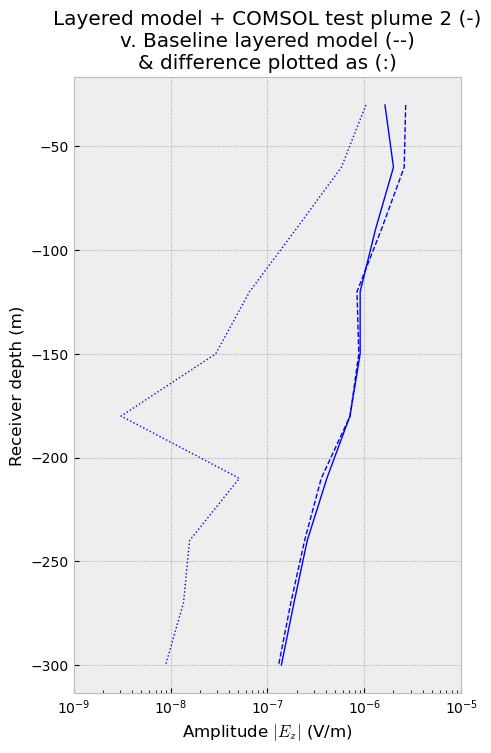

In [203]:
#QC reference receiver lines

sim_nr = 0

sim_key = list(simulations.keys())[sim_nr]
grad_simulation = simulations[sim_key][3]
model_name = models[simulations[sim_key][1]][1]
ref_name = models[simulations[sim_key][0]][1]

plt.figure(figsize=(5,8))
plt.title(''''''+model_name+''' (-)
v. '''+ref_name+''' (--)
& difference plotted as (:)''')
noisy = grad_simulation.data.observed[:, :, :]
clean = grad_simulation.data.synthetic[:, :, :]
noise = noisy - clean
for i, srcn in enumerate(simulation.survey.sources.keys()):
    for ii, freq in enumerate(simulation.survey.frequencies):
        plt.plot(np.sqrt(noisy.loc[srcn, :, freq].data.real**2 + noisy.loc[srcn, :, freq].data.imag**2),
                 rec_coords[2][:],
                 c=colors[i],
                 #label= 'noisy'#'xy: '+str(src_x[i])+', '+str(src_y[i]) # else None
                 )
        plt.plot(np.sqrt(clean.loc[srcn, :, freq].data.real**2 + clean.loc[srcn, :, freq].data.imag**2),
                 rec_coords[2][:],
                 '--',
                 color = colors[i],
                 #label = 'clean'
                 )
        plt.plot(amp_diff(noisy.loc[srcn, :, freq].data, clean.loc[srcn, :, freq].data),
         rec_coords[2][:],
         ':',
         color = colors[i],
         #label = 'noise'
         )
plt.xscale('log')
plt.legend(ncol=1, framealpha=0)
plt.ylabel('Receiver depth (m)')
plt.xlabel('Amplitude $|E_z|$ (V/m)')
ticks, labels = plt.xticks()
plt.xticks(ticks[1:-1])

#The relative noise dominates and has amplitude of 1% of the data

In [152]:
print(grad_simulation.misfit)

38566.60939363421


In [38]:
for i in np.arange(len(src_x)):
    print('source_nr '+str(i)+': x = '+str(src_x[i])+', y = '+str(src_y[i])+', az = '+str(src_az[i]))

NameError: name 'src_x' is not defined

#### Plotting the efields

[0, -300, -250] [0, 300, 0]
x position:  24.99999999999943
y_bounds:  -575.7505427216491  ,  575.7505427216479
z_bounds:  -249.99999999999852  ,  -24.999999999998522
[0, -300, -250] [0, 300, 0]
x position:  24.99999999999943
y_bounds:  -575.7505427216491  ,  575.7505427216479
z_bounds:  -249.99999999999852  ,  -24.999999999998522


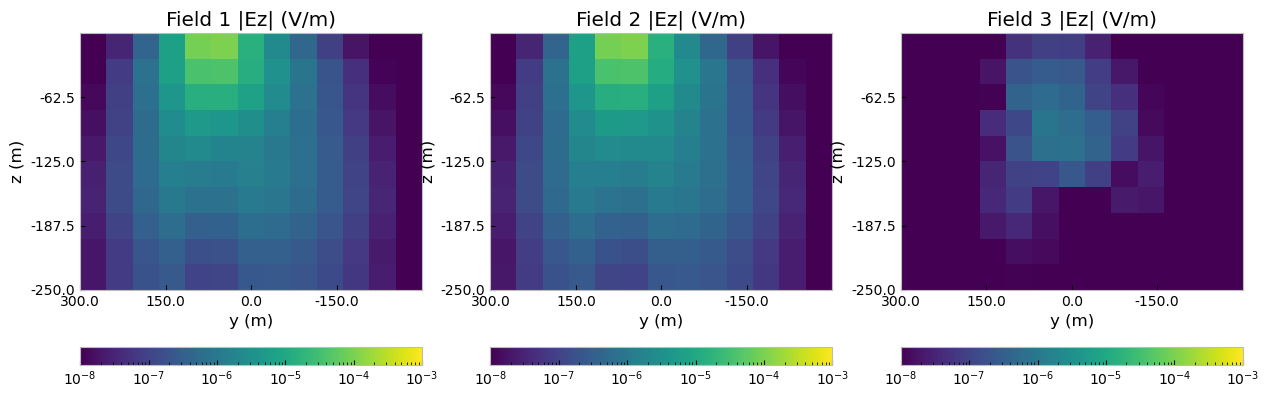

In [206]:
sim_nr = 0
src_nr = 0
fr_nr = 0

sim_key = list(simulations.keys())[sim_nr]
simulation = simulations[sim_key][2]
grad_simulation = simulations[sim_key][3]
new_grid = simulation.get_grid(list(src)[src_nr], frequencies[fr_nr])
efield_ref = simulation.get_efield(list(src)[src_nr], frequencies[fr_nr])
efield_meas = grad_simulation.get_efield(list(src)[src_nr], frequencies[fr_nr])

efield1 = crop_to_domain(efield_ref, new_grid, x_slice = 0, y_extent=300, zmin=-250, zmax=0)
efield2 = crop_to_domain(efield_meas, new_grid, x_slice = 0, y_extent=300, zmin=-250, zmax=0)
efield3 = np.abs(efield2)-np.abs(efield1)

manual_plot_slice_3x(efield1, efield2, efield3, y_extent=-300, zmin=-250, zmax=0, size_y = 6.4, size_z = 4.8, vmin = 1e-8, vmax = 1e-3)
#edit_manual_plot_slice_3x(efield1, efield2, efield3, y_extent=-300, zmin=-250, zmax=0, size_y = 6.4, size_z = 4.8, vmin = 1e-8, vmax = 1e-3)

#### Plotting the gradient

In [175]:
sim_nr = 0

sim_key = list(simulations.keys())[sim_nr]
gradient = simulations[sim_key][4]
gradient_flat = gradient.ravel('F')
max_gradient = max(gradient_flat)
rel_gradient = np.divide(gradient_flat,max_gradient)

NameError: name 'src_x' is not defined

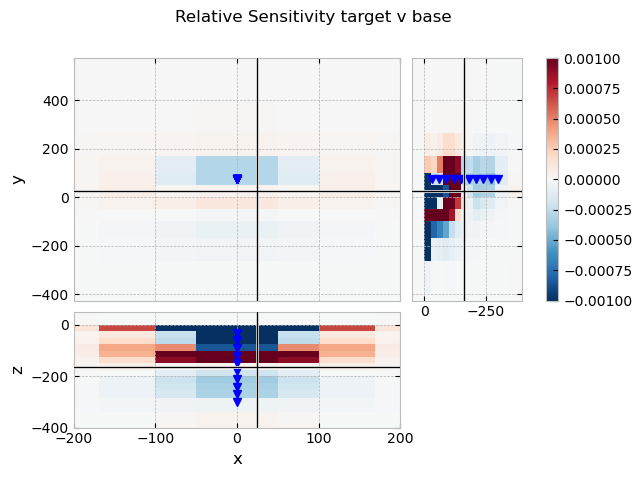

In [176]:
#Plot the gradient

#Set the gradient of air and water to NaN, this will eventually move directly into emgd3 (active and inactive cells).
#subsurface = (res < 1e3)
#grad[~subsurface] = np.nan

grid.plot_3d_slicer(
        rel_gradient,
        pcolor_opts={'cmap': 'RdBu_r',
                     'norm': Normalize(vmin=-1e-3, vmax=1e-3)},
        xlim=[-200, 200],
        ylim=[-426, 574], #center at receiver location
        zlim=[-400, 50],
        zslice=-160,
        yslice = 0)
fig = plt.gcf()
fig.suptitle('Relative '+sim_key)
axs = fig.get_children()
rec_coords = [rec_x, rec_y, rec_z]
axs[1].plot(rec_coords[0], rec_coords[1], 'bv')
axs[2].plot(rec_coords[0], rec_coords[2], 'bv')
axs[3].plot(rec_coords[2], rec_coords[1], 'bv')
src_coords = [src_x, src_y, src_z]
axs[1].plot(src_coords[0], src_coords[1], 'r*')
axs[2].plot(src_coords[0], src_coords[2], 'r*')
axs[3].plot(src_coords[2], src_coords[1], 'r*')
axs[1].grid(False)
axs[2].grid(False)
axs[3].grid(False)

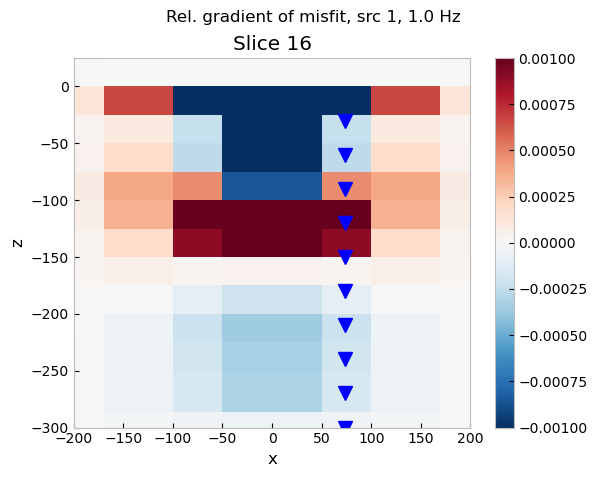

In [267]:
#Focus on the y,z plane

#Plot the simulated electric field
f0 = grid.plot_slice(
    rel_gradient,
    pcolor_opts={'cmap': 'RdBu_r',
             'norm': Normalize(vmin=-1e-3, vmax=1e-3)},
    normal = 'Y',
    range_x=[-200, 200], #y extent
    range_y=[-300, 25], #z extent
    slice_loc=0 #, defaults to 0
)
fig = plt.gcf()
fig.suptitle('Rel. gradient of misfit, src '+str(src_nr+1)+', '+str(frequencies[fr_nr])+' Hz')
axs = fig.get_children()
axs[1].grid(False)
rec_coords = survey.receiver_coordinates()
src_coords = survey.source_coordinates()
axs[1].plot(rec_coords[1], rec_coords[2], 'bv', markersize = 10)
#axs[1].plot(src_coords[1], src_coords[2], 'r*', markersize = 20)
fig.colorbar(f0[0], ax = axs[1])

In [ ]:
#Plot absolute value of the gradient

grid.plot_3d_slicer(
        np.abs(rel_gradient),
        pcolor_opts={'norm': LogNorm(
                         vmin=1e-9, vmax=1e-4)},
        xlim=[-200, 200],
        ylim=[-426, 574], #center at receiver location
        zlim=[-400, 50],
        zslice=-160,
        yslice = 74)
fig = plt.gcf()
fig.suptitle('Absolute rel. gradient of baseline with uniform 25 Ohmmm starting model')
axs = fig.get_children()
axs[1].plot(rec_coords[0], rec_coords[1], 'bv')
axs[2].plot(rec_coords[0], rec_coords[2], 'bv')
axs[3].plot(rec_coords[2], rec_coords[1], 'bv')
axs[1].plot(src_coords[0], src_coords[1], 'r*')
axs[2].plot(src_coords[0], src_coords[2], 'r*')
axs[3].plot(src_coords[2], src_coords[1], 'r*')
axs[1].grid(False)
axs[2].grid(False)
axs[3].grid(False)

### Finite difference gradient

In [99]:
data_misfit =  grad_simulation.misfit

In [142]:
print(data_misfit)

38566.60939363421


In [119]:
print(model_target)

Model: resistivity; isotropic; 32 x 32 x 40 (40,960)


In [268]:
# Define epsilon (some small resistivity value, Ohmm).
epsilon = 1

# Define the cross-section.
iy = grid.shape_cells[1]//2


def comp_fd_grad(ixiz):
    """Compute forward-FD gradient for one cell."""

    # Copy the computational model.
    fd_model = model_base.copy()

    # Add conductivity-epsilon to this (ix, iy, iz) cell.
    fd_model.property_x[ixiz[0], iy, ixiz[1]] += epsilon

    # Create a new simulation with this model
    simulation_fd = emg3d.simulations.Simulation(
        name='FD Gradient Test',
        survey=noisy_survey, 
        model=fd_model,
        gridding='same',
        max_workers=1,
        solver_opts={'verb': 1},
        receiver_interpolation='linear',  # For proper adjoint-state gradient
    )

    # Switch-of progress bar in this case
    simulation_fd._tqdm_opts['disable'] = True

    # Get misfit
    fd_data_misfit = simulation_fd.misfit
    #print(fd_data_misfit)
    #print(data_misfit)
    #print(float((fd_data_misfit - data_misfit)/epsilon))

    # Return gradient
    return float((fd_data_misfit - data_misfit)/epsilon)

In [269]:
import itertools

In [270]:
# Initiate FD gradient.
fd_grad = np.zeros_like(gradient)

# Get all ix-iz combinations (without air/water).
ixiz = list(itertools.product(
    range(grid.shape_cells[0]),
    range(len(grid.cell_centers_z[grid.cell_centers_z < 0])))
)

# Wrap it asynchronously
#out = emg3d._multiprocessing.process_map(
#        comp_fd_grad,
#        ixiz,
#        max_workers=1,  # Adjust max worker here!
#)

for i, (ix, iz) in enumerate(ixiz):
    #print(i)
    #print(ix)
    #print(iz)
    fd_grad_i = comp_fd_grad([ix, iz])
    fd_grad[ix, iy, iz] = fd_grad_i
    #print(fd_grad_i)

# Collect result
#for i, (ix, iz) in enumerate(ixiz):
#    fd_grad[ix, iy, iz] = out[i]

In [271]:
from matplotlib.colors import LogNorm, SymLogNorm
from matplotlib.patches import Rectangle

In [272]:
print(ixiz[-5:])
print(np.shape(fd_grad))
print(fd_grad[30,30,30])
print(data_misfit)

[(31, 19), (31, 20), (31, 21), (31, 22), (31, 23)]
(32, 32, 40)
0.0
38566.60939363421


(240000.0, 260000.0)

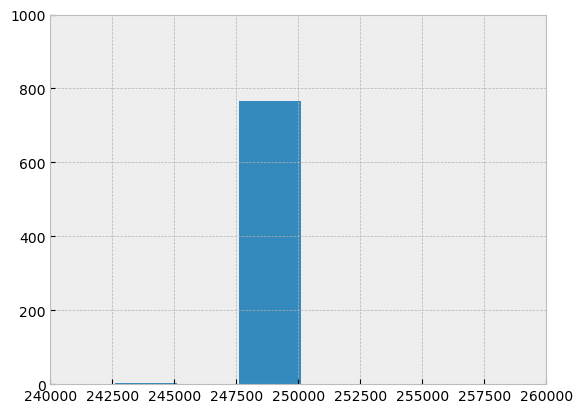

In [278]:
plt.hist(fd_grad.flatten(), bins=100)
plt.ylim([0, 1000])
plt.xlim([240000, 260000])

In [336]:
max_fd_grad = np.max(fd_grad)

max_fd_grad = max(fd_grad.flatten())
rel_fd_grad = 1-np.divide(fd_grad.flatten(),max_fd_grad)

(0.9, 1.1)

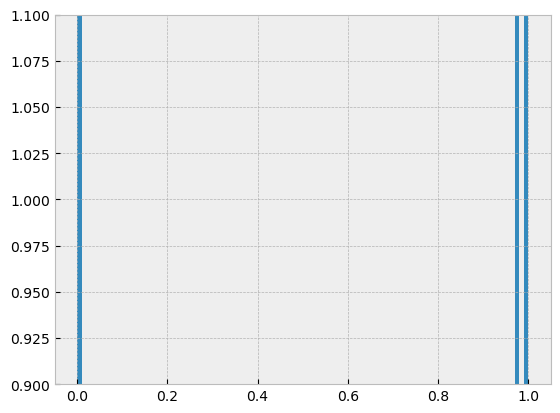

In [315]:
plt.hist(rel_fd_grad, bins=100)
plt.ylim([0.9, 1.1])
#plt.xlim([240000, 260000])

In [338]:
fd_grad_flat = fd_grad.flatten()/max_fd_grad
for i in np.arange(len(fd_grad_flat)):
    if fd_grad_flat[i]>0:
        print(rel_fd_grad[i])

0.006836803890051479
0.0068368038900618044
0.006836803890061582
0.006836803890068244
0.0068368038900223915
0.006836803890055476
0.006836803890056475
0.006836803890083454
0.006836803889973986
0.00683680389001784
0.006836803890041709
0.00683680389004826
0.0068368038900720185
0.006836803890093446
0.00683680389007757
0.006836803890080345
0.0068368038900717965
0.006836803890088339
0.006836803890085008
0.006836803890064802
0.006836803890086451
0.006836803890078569
0.006836803890068577
0.0068368038900866734
0.0068368038900473715
0.006836803890079457
0.006836803890069243
0.006836803890081566
0.006836803890036158
0.0068368038900473715
0.00683680389005481
0.0068368038900820105
0.006836803890015952
0.006836803890039156
0.0068368038900569195
0.006836803890054588
0.006836803890066689
0.00683680389009278
0.006836803890084564
0.006836803890082455
0.006836803890082455
0.006836803890062471
0.006836803890081566
0.006836803890070353
0.006836803890085008
0.0068368038900817885
0.006836803890085563
0.006836

In [346]:
print(rel_fd_grad[:5])

[1. 1. 1. 1. 1.]


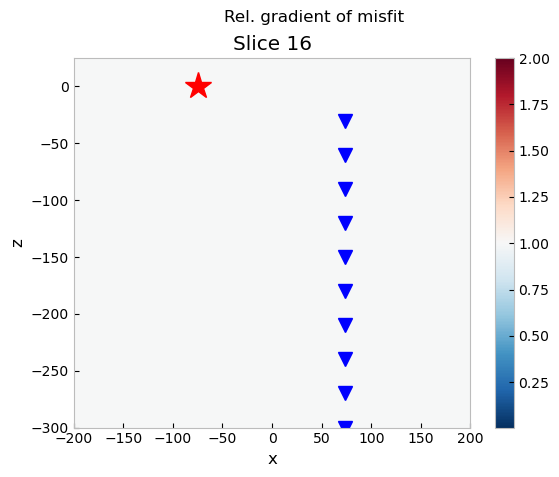

In [349]:
#Focus on the x,z plane (y=74)

f0 = grid.plot_slice(
    rel_fd_grad,
    pcolor_opts={'cmap': 'RdBu_r',
             'norm': Normalize(vmin=0.005, vmax=2)},
    normal = 'Y',
    range_x=[-200, 200], #y extent
    range_y=[-300, 25], #z extent
    slice_loc=0 #, defaults to 0
)
fig = plt.gcf()
fig.suptitle('Rel. gradient of misfit')
axs = fig.get_children()
axs[1].grid(False)
rec_coords = survey.receiver_coordinates()
src_coords = survey.source_coordinates()
axs[1].plot(rec_coords[1], rec_coords[2], 'bv', markersize = 10)
axs[1].plot(src_coords[1], src_coords[2], 'r*', markersize = 20)
fig.colorbar(f0[0], ax = axs[1])

192833.9388641387
236704.7459716507
0.0


C:\Users\suzannevannoor\AppData\Local\Temp\ipykernel_14736\546578994.py:7: RuntimeWarning: overflow encountered in divide
  diff_sign = np.sign(gradient/np.where(abs(fd_grad) < tiny, tiny, fd_grad))


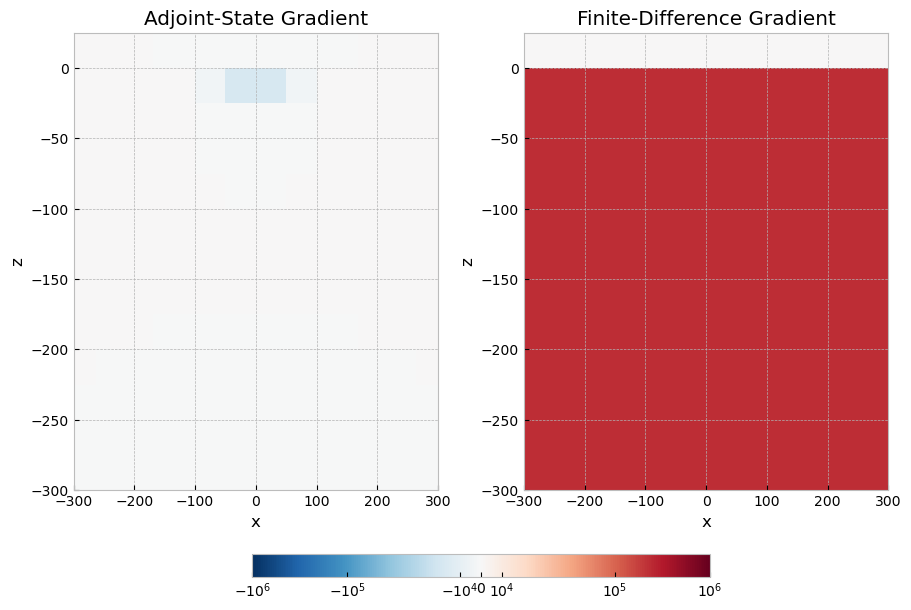

In [225]:
    # Compute NRMSD between AS and FD (%).
    nrmsd = 200*abs(gradient-fd_grad)/(abs(gradient)+abs(fd_grad))
    nrmsd[fd_grad == 0] = np.nan
    
    # Compute sign.
    tiny = np.finfo(float).tiny  # Avoid division by zero.
    diff_sign = np.sign(gradient/np.where(abs(fd_grad) < tiny, tiny, fd_grad))
    
    
    def plot_diff(ax, diff):
        """Helper routine to show cells of big NRMSD or different sign."""
    
        for ix in range(grid.h[0].size):
            for iz in range(grid.h[2].size):
    
                if diff_sign[ix, iy, iz] < 0:
                    ax.add_patch(
                            Rectangle(
                                (grid.nodes_x[ix], grid.nodes_z[iz]),
                                grid.h[0][ix], grid.h[2][iz], fill=False,
                                color='k', lw=1))
    
                if nrmsd[ix, iy, iz] >= diff:
                    ax.add_patch(
                            Rectangle(
                                (grid.nodes_x[ix], grid.nodes_z[iz]),
                                grid.h[0][ix], grid.h[2][iz], fill=False,
                                color='m', linestyle='--', lw=0.5))
    
    
    def set_axis(axs, i):
        """Helper routine to adjust subplots."""
    
        # Show source and receiver.
        axs[i].plot(rec_coords[0], rec_coords[2], 'bv')
        axs[i].plot(src_coords[0], src_coords[2], 'r*')
    
        # x-label.
        axs[i].set_xlabel('Easting')
    
        # y-label depending on column.
        if i == 0:
            axs[i].set_ylabel('Depth')
        else:
            axs[i].set_ylabel('')
            axs[i].axes.yaxis.set_ticklabels([])
    
        # Set limits.
        axs[i].set_xlim(-3000, 3000)
        axs[i].set_ylim(-4000, -1900)
    
    
    # Plotting options.
    vmin, vmax = 5e4, 1e6
    pcolor_opts = {'cmap': 'RdBu_r',
                   'norm': SymLogNorm(linthresh=vmin, base=10,
                                      vmin=-vmax, vmax=vmax)}
    
    fig, axs = plt.subplots(
            figsize=(9, 6), nrows=1, ncols=2, constrained_layout=True)
    
    max_grad = np.max(gradient)
    print(max_grad)
    
    # Adjoint-State Gradient
    f0 = grid.plot_slice(gradient, normal='Y', ind=iy, ax=axs[0],
                              pcolor_opts=pcolor_opts, range_x=[-300, 300], range_y=[-300, 25])
    axs[0].set_title("Adjoint-State Gradient")
    #set_axis(axs, 0)
    #plot_diff(axs[0], 1)
    
    max_fd_grad = np.max(fd_grad)
    print(max_fd_grad)
    print(fd_grad[15, 15, 15])
    
    # Finite-Difference Gradient
    f1 = grid.plot_slice(fd_grad, normal='Y', ind=iy, ax=axs[1],
                              pcolor_opts=pcolor_opts, range_x=[-300, 300], range_y=[-300, 25])
    axs[1].set_title("Finite-Difference Gradient")
    #set_axis(axs, 1)
    #plot_diff(axs[1], 1)
    
    fig.colorbar(f0[0], ax=axs, orientation='horizontal', fraction=0.05)

## Results

### Plotting the efields

### Plotting the gradient

In [101]:
print(rec_y)

[74 74 74 74 74 74 74 74 74 74 74 74 74 74 74 74 74 74 74 74 74 74 74 74
 74 74 74 74 74 74 74 74 74 74 74 74 74 74 74 74]


In [ ]:
plt.rcParams.update({'font.size':10})

In [ ]:
emg3d.Report()